In [94]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from scipy.io import wavfile

In [ ]:
freq = 44100
middle_c = 261.625565
sps = 10000
delta_phase = np.pi / 2 * 0.05
flag = "SSM{261.63Hz_my_beloved}"

signal_len = sps * len(flag) * 8
t = np.arange(signal_len) / freq
flag_bits = np.unpackbits(np.frombuffer(flag.encode(), dtype=np.uint8)).astype(bool)

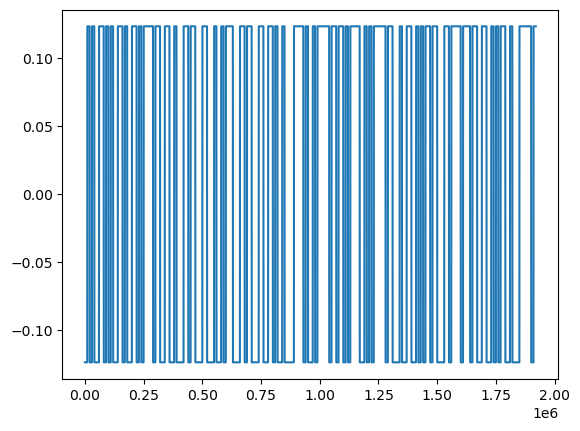

In [101]:
flag_phase = np.ones(signal_len) * delta_phase
flag_phase[~flag_bits.repeat(sps)] = -delta_phase
flag_phase *= np.pi / 2
plt.plot(flag_phase)

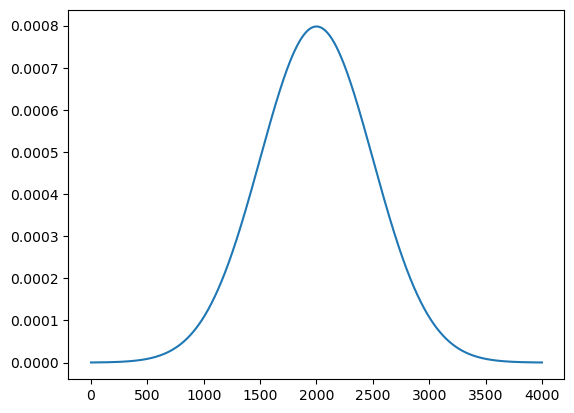

In [102]:
filt = sp.stats.norm.pdf(np.arange(-2000, 2001), scale=500)
plt.plot(filt)

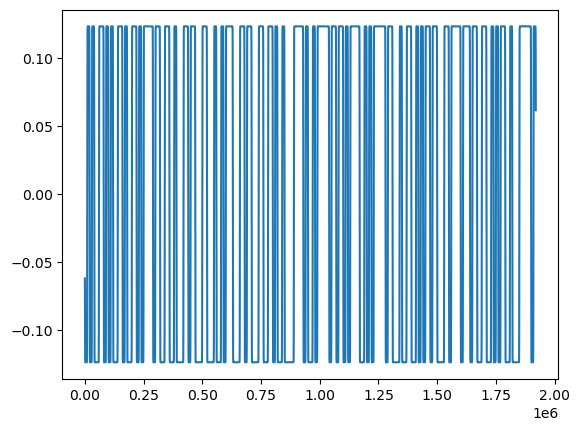

In [103]:
filtered_flag_phase = np.convolve(flag_phase, filt, mode="same")
plt.plot(filtered_flag_phase)

In [104]:
signal = np.sin(2 * np.pi * t * middle_c + filtered_flag_phase)

In [105]:
wavfile.write("c.wav", freq, signal * 0.5)